In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv('./Dataset/retail_sales_dataset.csv')
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


Dataset has 999 Rows of data and 9 COlumns

In [4]:
# Top 10 entries in dataset
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


In [ ]:
# Last 10 entries in dataset
df.tail(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
990,991,2023-12-26,CUST991,Female,34,Clothing,2,50,100
991,992,2023-08-21,CUST992,Female,57,Electronics,2,30,60
992,993,2023-02-06,CUST993,Female,48,Electronics,3,50,150
993,994,2023-12-18,CUST994,Female,51,Beauty,2,500,1000
994,995,2023-04-30,CUST995,Female,41,Clothing,1,30,30
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [ ]:
# List of columns in dataset
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [12]:
# Data type of each column
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

4 columns are of catagorical data. 5 columns are of numerical type

In [9]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [13]:
# Checking unique values in each column
df.nunique()

Transaction ID      1000
Date                 345
Customer ID         1000
Gender                 2
Age                   47
Product Category       3
Quantity               4
Price per Unit         5
Total Amount          18
dtype: int64

In [19]:
# Checking null values
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

No null value in dataset

In [22]:
df.duplicated().sum()

np.int64(0)

No duplicate value in dataset

In [24]:
# Converting object type into date time
df['Date'] = pd.to_datetime(df['Date'])

In [25]:
df.dtypes

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

In [30]:
numerical_columns = df.select_dtypes(include=['number'])
numerical_columns

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
0,1,34,3,50,150
1,2,26,2,500,1000
2,3,50,1,30,30
3,4,37,1,500,500
4,5,30,2,50,100
...,...,...,...,...,...
995,996,62,1,50,50
996,997,52,3,30,90
997,998,23,4,25,100
998,999,36,3,50,150


In [31]:
categorical_columns = df.select_dtypes(include=['object','category'])

In [32]:
categorical_columns

,Customer ID,Gender,Product Category
0,CUST001,Male,Beauty
1,CUST002,Female,Clothing
2,CUST003,Male,Electronics
3,CUST004,Male,Clothing
4,CUST005,Male,Beauty
...,...,...,...
995,CUST996,Male,Clothing
996,CUST997,Male,Beauty
997,CUST998,Female,Beauty
998,CUST999,Female,Electronics


# Univarient analysis

In [36]:
def hist_plot(df:pd.DataFrame,column:'str'):
    plt.Figure(figsize=[15,5])
    sns.histplot(data=df,x=column,kde=True,bins=10)
    plt.title(f"Histogram of {column}")
    plt.tight_layout()
    plt.show()

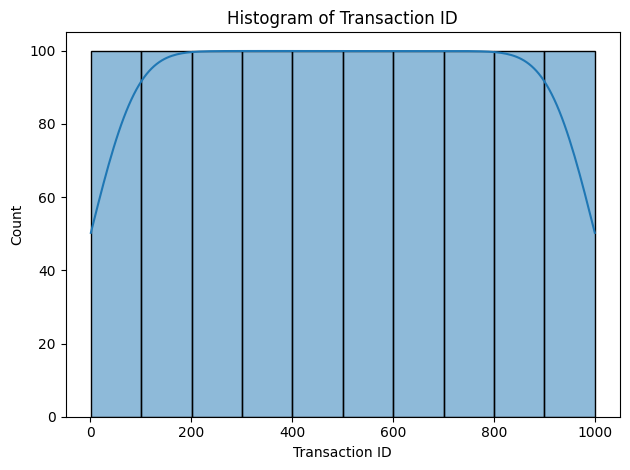

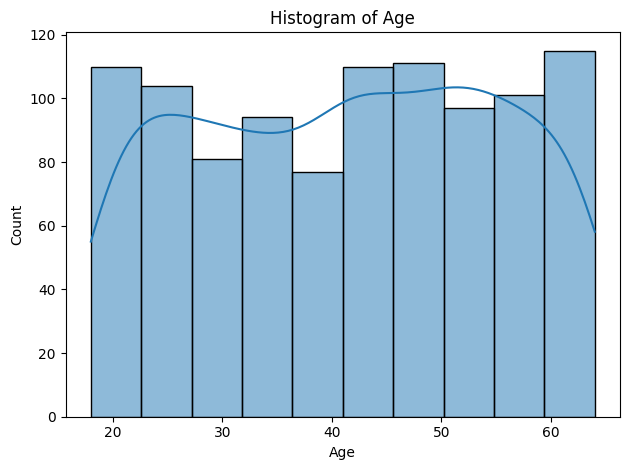

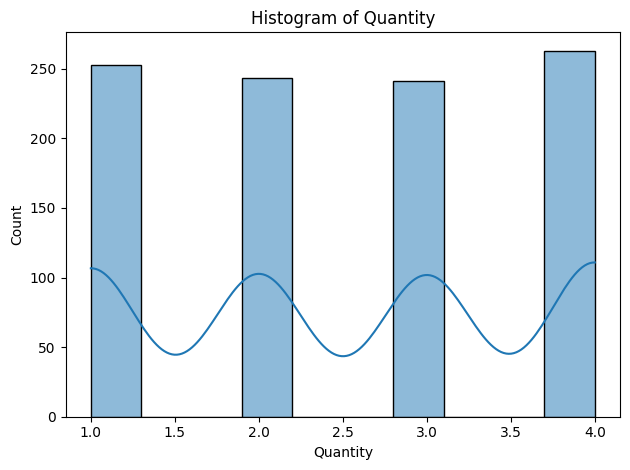

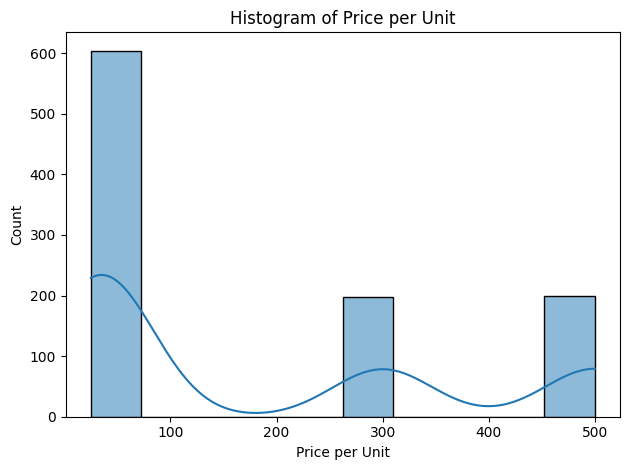

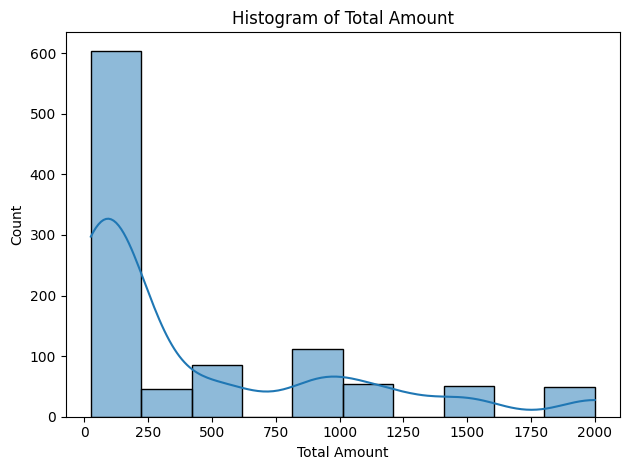

In [37]:
for col in numerical_columns:
    hist_plot(numerical_columns,col)

In [38]:
def count_plot(df:pd.DataFrame,column:'str'):
    plt.Figure(figsize=[15,5])
    sns.countplot(data=df,x=column)
    plt.title(f"Countplot of {column}")
    plt.tight_layout()
    plt.show()

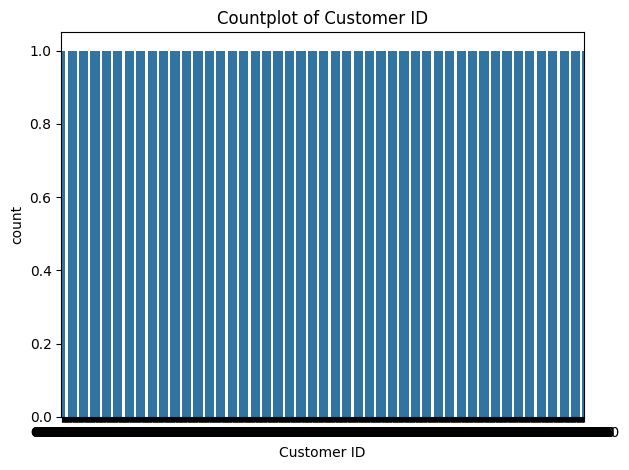

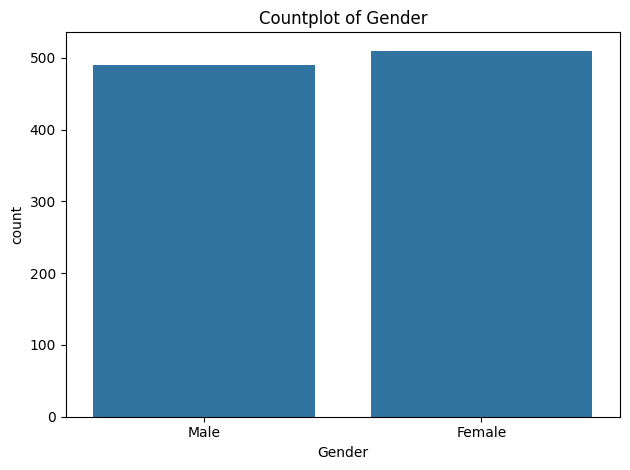

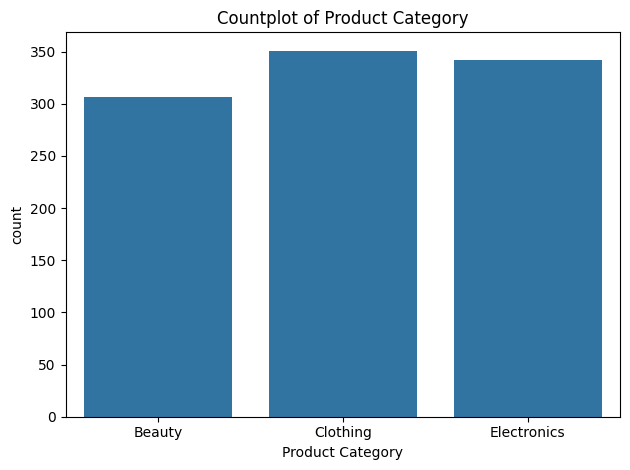

In [39]:
for col in categorical_columns:
    count_plot(categorical_columns,col)

Drop Transaction id and customer id as they do not give any insight.


In [ ]:
numerical_columns=numerical_columns.drop('Transaction ID',axis=1)

In [45]:
numerical_columns

,Age,Quantity,Price per Unit,Total Amount
0,34,3,50,150
1,26,2,500,1000
2,50,1,30,30
3,37,1,500,500
4,30,2,50,100
...,...,...,...,...
995,62,1,50,50
996,52,3,30,90
997,23,4,25,100
998,36,3,50,150


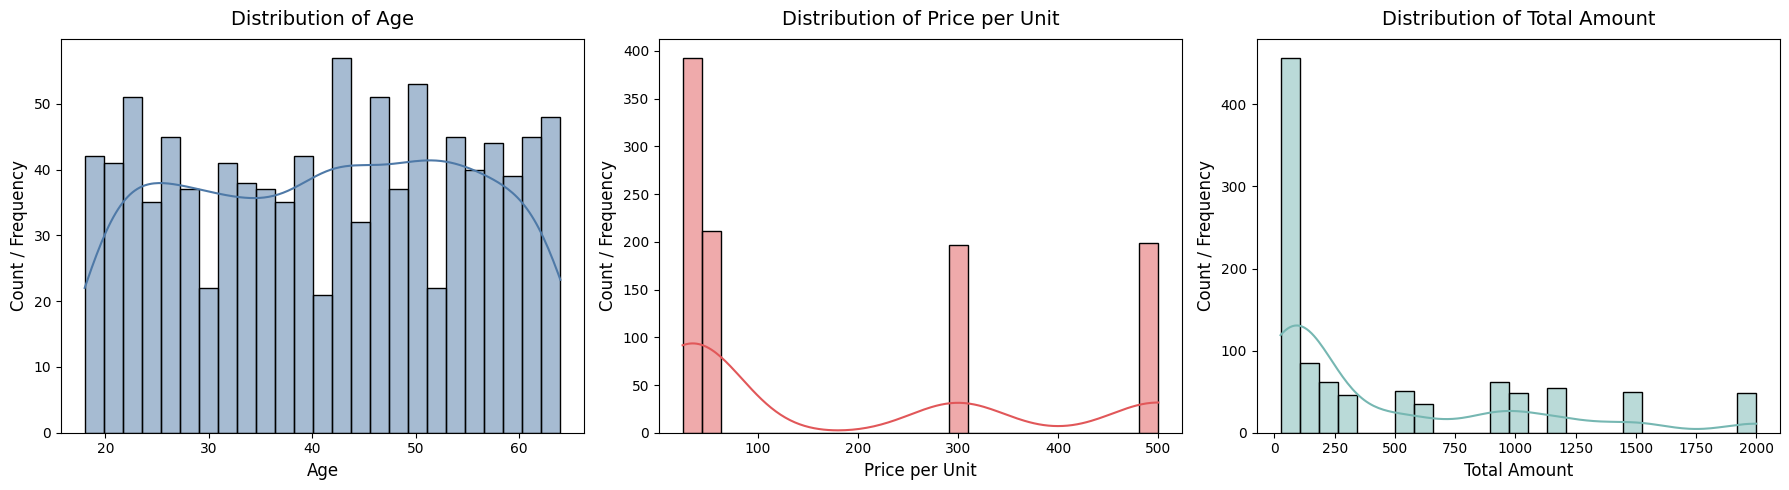

In [58]:
numerical_cols = ["Age", "Price per Unit", "Total Amount"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numerical_cols):
    if col in df.columns:
        sns.histplot(
            data=df,
            x=col,
            kde=True,
            bins=25,
            color=["#4e79a7", "#e15759", "#76b7b2"][i],
            ax=axes[i],
        )
        axes[i].set_title(f"Distribution of {col}", fontsize=14, pad=10)
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel("Count / Frequency", fontsize=12)

plt.tight_layout()
plt.show()


Insights:
1. Age is uniform distribution. The bars remain relatively level across the top from age 18 to 64, with the trendline wavering slightly but staying balanced.
2. People with age of 20,30,40,50 has low frequency.
3. Sotre has capturing equal market share from Gen Z, Millennials, and Gen X shoppers.  
4. High volume for Item below 100 Price per unit.
5. Middle tir and premium tire market has almost same frequency.
6. There is huge gap between 100 to 300 price per unit. So new products can be added in this gap. Also between 300 and 500.
7.  The vast majority of your individual transactions are small, low-value baskets.

In [46]:
categorical_columns=categorical_columns.drop('Customer ID',axis=1)

In [47]:
categorical_columns

,Gender,Product Category
0,Male,Beauty
1,Female,Clothing
2,Male,Electronics
3,Male,Clothing
4,Male,Beauty
...,...,...
995,Male,Clothing
996,Male,Beauty
997,Female,Beauty
998,Female,Electronics


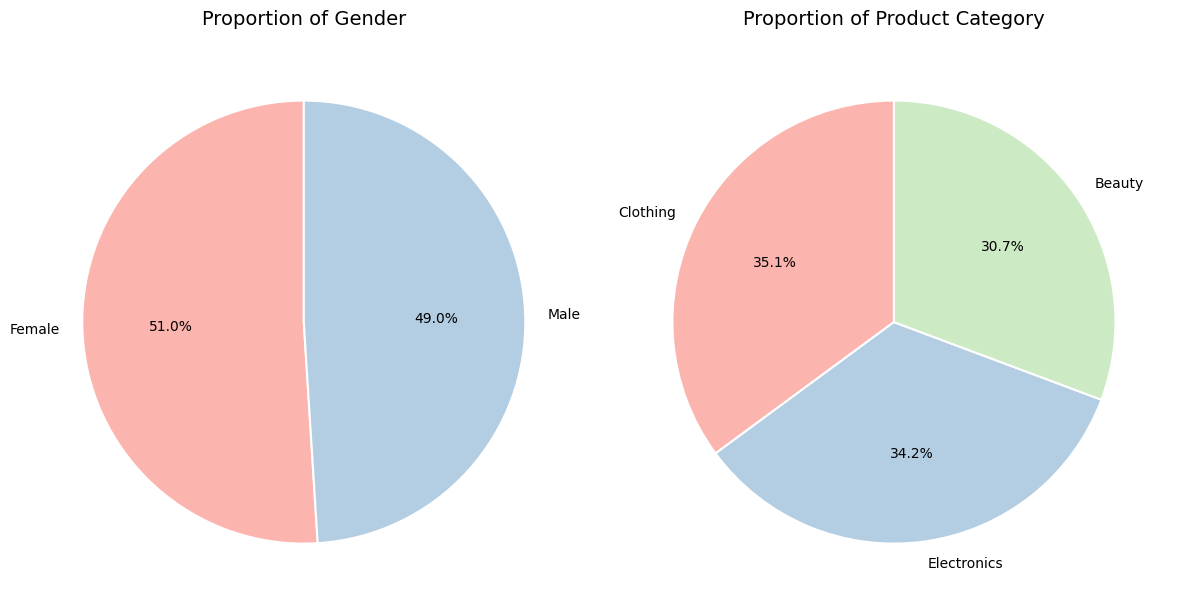

In [53]:
categorical_cols = ["Gender", "Product Category"]

num_cols = len(categorical_cols)
fig, axes = plt.subplots(1, num_cols, figsize=(6 * num_cols, 6))

if num_cols == 1:
    axes = [axes]

for i, col in enumerate(categorical_cols):
    if col in df.columns:
        # Get counts for each unique category
        category_counts = df[col].value_counts()

        
        axes[i].pie(
            category_counts,
            labels=category_counts.index,
            autopct="%1.1f%%",  
            startangle=90,  
            colors=plt.cm.Pastel1.colors, 
            wedgeprops={"edgecolor": "white", "linewidth": 1.5},
        )

        axes[i].set_title(f"Proportion of {col}", fontsize=14, pad=15)

plt.tight_layout()
plt.show()

1. Ratio of male and female in shoping list is almost same. No gender bias in market.
2. Clothing and electronic category has same percentage of market share.
3. Store can focus on increse in beauty sale. As it lag behind a bit. 

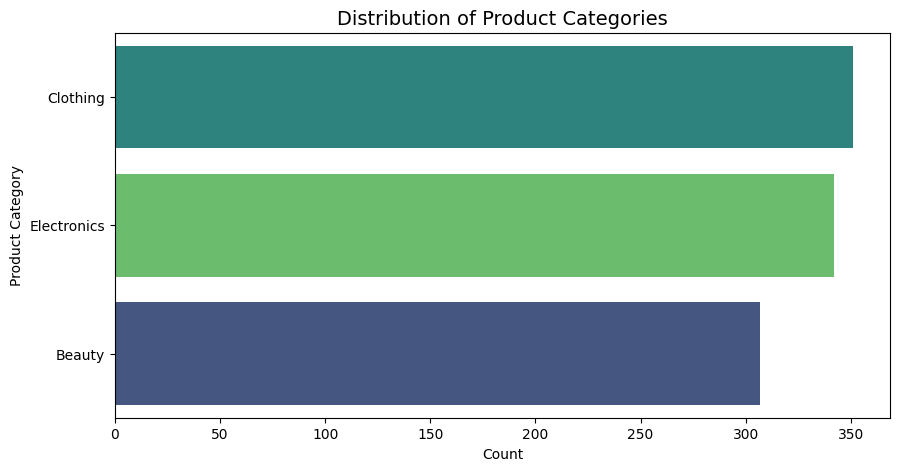

In [57]:
plt.figure(figsize=(10, 5))


sns.countplot(
    data=df,
    y="Product Category",
    order=df["Product Category"].value_counts().index,
    palette="viridis",
    hue="Product Category"
)

plt.title("Distribution of Product Categories", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Product Category")
plt.show()

# Bivarient and Mutlivarient analysis

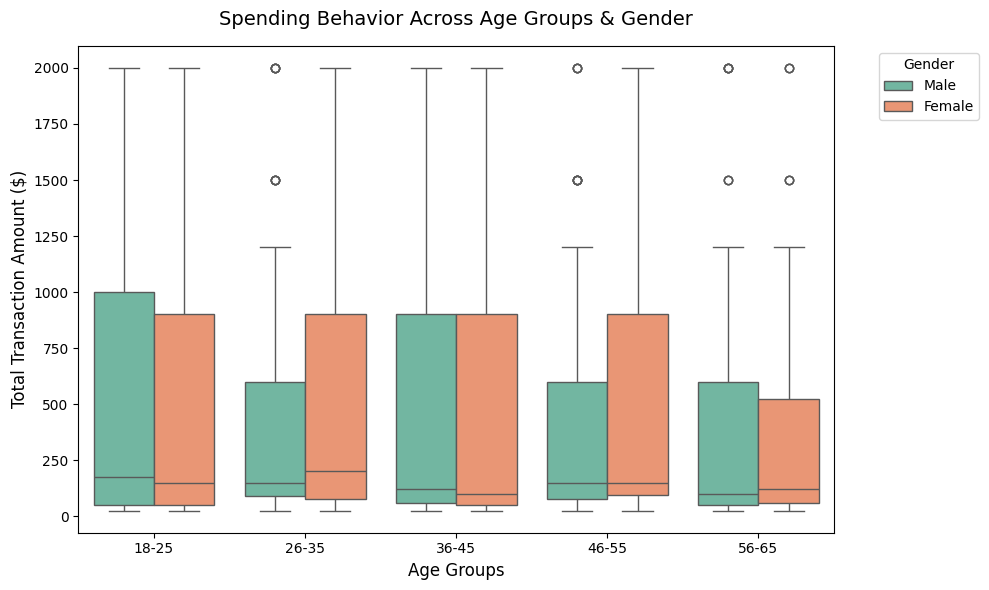

In [54]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65"],
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Age_Group", y="Total Amount", hue="Gender", palette="Set2")

plt.title("Spending Behavior Across Age Groups & Gender", fontsize=14, pad=15)
plt.xlabel("Age Groups", fontsize=12)
plt.ylabel("Total Transaction Amount ($)", fontsize=12)


plt.legend(title="Gender", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

1. Bearly any outliers in dataser.
2. Mean transcation per day is below 250.
3. Customers aren't spending random amounts; they are simply buying your pre-established product bundles.
4. Males between 26-35 and 46-55 have low total transation amount comapired to almost equal transtion in othre age group.
5. Implement cross-selling recommendations at checkout to help lift that low median line across the board.

C:\Users\dhira\AppData\Local\Temp\ipykernel_3344\1346759220.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


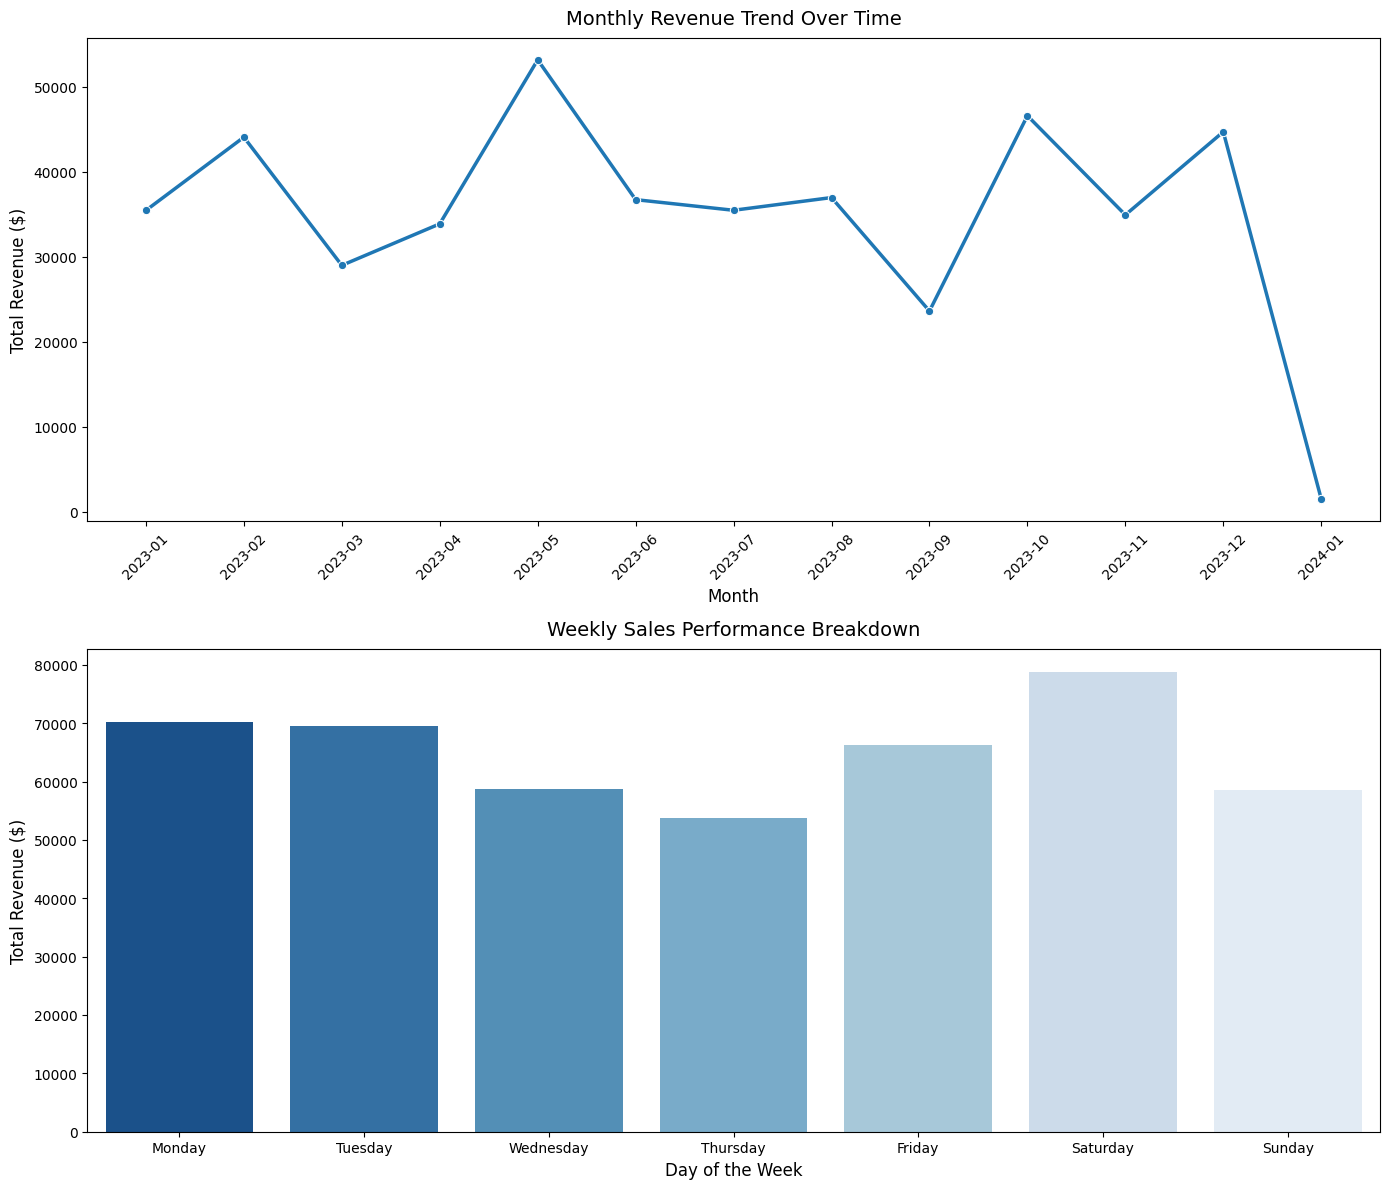

In [61]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month_Year"] = df["Date"].dt.to_period("M")
df["Day_of_Week"] = df["Date"].dt.day_name()

monthly_sales = (
    df.groupby("Month_Year")
    .agg({"Total Amount": "sum", "Transaction ID": "count"})
    .reset_index()
)
monthly_sales["Month_Year"] = monthly_sales["Month_Year"].astype(str)

days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
weekly_sales = (
    df.groupby("Day_of_Week")
    .agg({"Total Amount": "sum", "Quantity": "sum"})
    .reindex(days_order)
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

sns.lineplot(
    data=monthly_sales,
    x="Month_Year",
    y="Total Amount",
    marker="o",
    linewidth=2.5,
    color="#1f77b4",
    ax=axes[0],
    
)
axes[0].set_title("Monthly Revenue Trend Over Time", fontsize=14, pad=10)
axes[0].set_xlabel("Month", fontsize=12)
axes[0].set_ylabel("Total Revenue ($)", fontsize=12)
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=weekly_sales,
    x="Day_of_Week",
    y="Total Amount",
    palette="Blues_r",
    ax=axes[1],
)
axes[1].set_title("Weekly Sales Performance Breakdown", fontsize=14, pad=10)
axes[1].set_xlabel("Day of the Week", fontsize=12)
axes[1].set_ylabel("Total Revenue ($)", fontsize=12)

plt.tight_layout()
plt.show()

1. The extreme cliff-dive at the very end of the line chart in 2024-01, revenue falls almost to zero. dataset likely only contains transactions up to the first few days of January 2024.